# 4, 5 (everything else but 6 in the other file)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
T_data = pd.read_csv('./data/titanic.csv')
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
T_data.describe(include="all")

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,3,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,third,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,491,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,445.000000,446.000000,0.383838,NaN,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,257.353842,0.486592,NaN,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,0.000000,NaN,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,222.500000,223.500000,0.000000,NaN,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,445.000000,446.000000,0.000000,NaN,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,667.500000,668.500000,1.000000,NaN,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


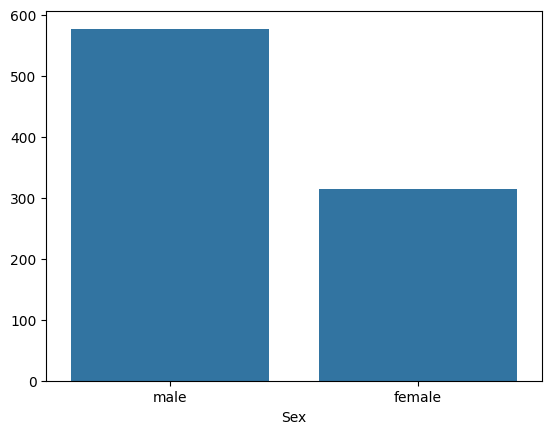

Sex
male      577
female    314
Name: count, dtype: int64


In [4]:
counts_sex = T_data["Sex"].value_counts()
sns.barplot(x=counts_sex.index, y=counts_sex.values)
plt.show()
print(counts_sex)

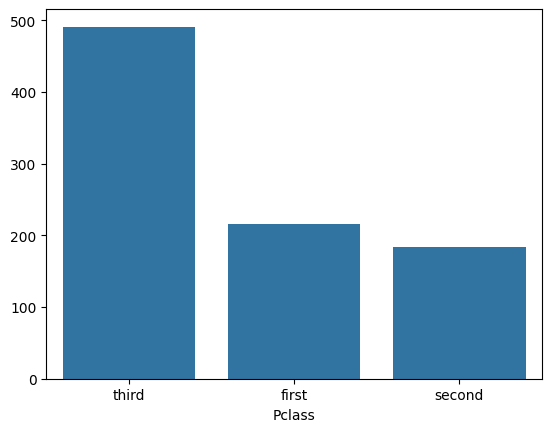

Pclass
third     491
first     216
second    184
Name: count, dtype: int64


In [5]:
counts_pclass = T_data["Pclass"].value_counts()
sns.barplot(x=counts_pclass.index, y=counts_pclass.values)
plt.show()
print(counts_pclass)

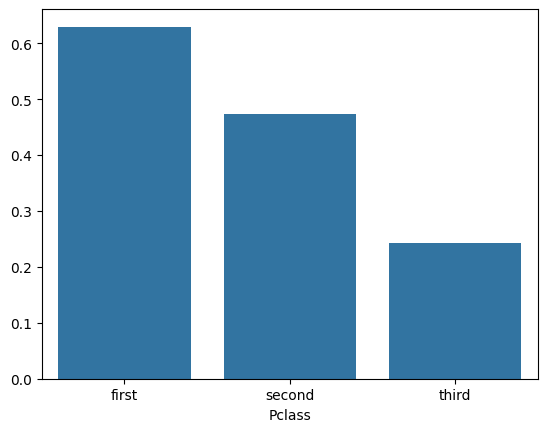

In [6]:
surv_pclass = T_data.groupby("Pclass")["Survived"].mean()
sns.barplot(x=surv_pclass.index, y=surv_pclass.values)
plt.show()

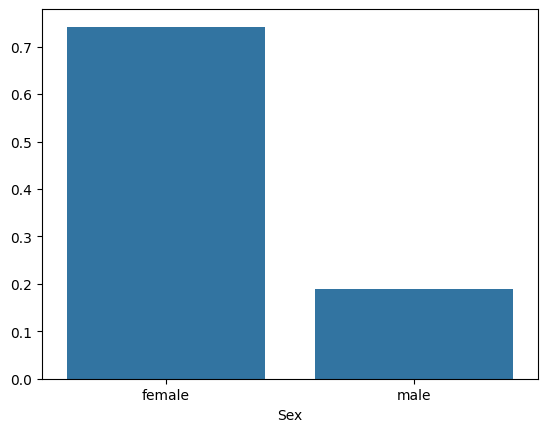

In [7]:
surv_sex = T_data.groupby("Sex")["Survived"].mean()
sns.barplot(x=surv_sex.index, y=surv_sex.values)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluate_dataset(df, target="Survived", name="Baseline"): # random forest
    X = df.drop(columns=[target, "PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: accuracy {acc:.4f}")
    return acc

In [9]:
df_baseline = T_data.copy()
evaluate_dataset(df_baseline, name="Baseline")

Baseline: accuracy 0.8156


0.8156424581005587

In [10]:
df_t1 = df_baseline.copy()
if df_t1["Pclass"].dtype == object:
    df_t1["Pclass"] = df_t1["Pclass"].replace({'first': 1, 'second': 2, 'third': 3})

df_t2 = df_t1.copy()
df_t2["FamilySize"] = df_t2["SibSp"] + df_t2["Parch"] + 1
evaluate_dataset(df_t2, name="FamilySize")

FamilySize: accuracy 0.8045


0.8044692737430168

In [11]:
df_t3 = df_t2.copy()
df_t3["Title"] = df_t3["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
evaluate_dataset(df_t3, name="Title Extractions")

Title Extractions: accuracy 0.8268


0.8268156424581006

In [12]:
df_t4 = df_t3.copy()
df_t4 = df_t4.drop(columns=["SibSp", "Parch"], errors="ignore")
evaluate_dataset(df_t4, name="dropped columns SibSp and Parch")

dropped columns SibSp and Parch: accuracy 0.8268


0.8268156424581006

In [13]:
df_t5 = df_t4.copy()
rare_titles = df_t5["Title"].value_counts()[df_t5["Title"].value_counts() < 10].index
df_t5["Title"] = df_t5["Title"].replace(rare_titles, "RareTitle")
evaluate_dataset(df_t5, name="rare titles grouped")

rare titles grouped: accuracy 0.8268


0.8268156424581006

# 6

In [14]:
def preprocess_titanic(df):
    df_clean = df.copy()
    if df_clean["Pclass"].dtype == object:
        df_clean["Pclass"] = df_clean["Pclass"].replace({'first': 1, 'second': 2, 'third': 3})

    if "SibSp" in df_clean.columns and "Parch" in df_clean.columns:
        df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
        df_clean = df_clean.drop(columns=["SibSp", "Parch"])

    if "Name" in df_clean.columns:
        df_clean["Title"] = df_clean["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
        rare_titles = df_clean["Title"].value_counts()[df_clean["Title"].value_counts() < 10].index
        df_clean["Title"] = df_clean["Title"].replace(rare_titles, "RareTitle")
    
    df_clean = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")
    
    return df_clean

final_df = preprocess_titanic(T_data)
final_df.head()

,Unnamed: 0,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title
0,0,0,third,male,22.0,7.2500,S,2,Mr
1,1,1,first,female,38.0,71.2833,C,2,Mrs
2,2,1,third,female,26.0,7.9250,S,1,Miss
3,3,1,first,female,35.0,53.1000,S,2,Mrs
4,4,0,third,male,35.0,8.0500,S,1,Mr
